

### **1. Import Libraries**

Import all required Python libraries for data handling, visualization, and machine learning.

---

### **2. Extracting Data or Getting Some Information**

Load the dataset and view its structure using functions like `.head()`, `.info()`, and `.describe()`.

---

### **3. View the Different Classes**

Identify the number of classes in the dataset and visualize them using a **pie plot** to check if the data is **highly imbalanced**.

---

### **4. Checking Correlation**

Use a **heatmap** to check correlation between features or classes to understand how strongly they are related.

---

### **5. Making Data Balanced**

Handle class imbalance by taking an equal number of samples (e.g., **1500 samples**) from each class to make the dataset balanced.

---

### **6. Checking Correlation Again**

Plot another **heatmap** to verify that after balancing, the classes are **highly separated** (low correlation) — which is a good sign for classification.

---

### **7. Checking Null Values**

Check for **missing or null values** in the dataset using `.isnull().sum()` and handle them if needed.

---

### **8. Cleaning the Dataset**

Perform text preprocessing steps:

* Remove stopwords
* Use `re` library to remove special characters, punctuation, and numbers
* Convert text to lowercase
* Split and remove extra spaces
* Apply stemming using **PorterStemmer** to reduce words to their root form

---

### **9. Train-Test Split**

Split the cleaned dataset into **training** and **testing** sets (e.g., 80% train, 20% test).

---

### **10. Apply TF-IDF Vectorizer**

Convert text into numerical features using **TF-IDF Vectorization** to prepare it for model training.

---

### **11. SVM**

Use SVM since the dataset is linearly separable and performs well for text classification tasks. It is efficient, interpretable.
---

### **12. Apply Evaluation Metrics**

Compute and display key performance metrics:

* **Accuracy**
* **Precision**
* **Recall**
* **F1-Score**

Also visualize the **Confusion Matrix** using a heatmap to evaluate model performance.




#### Importing Libraries

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from nltk.stem import   PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
import re
import pandas as pd
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import nltk
import joblib
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings("ignore")

### Extracting the data

In [2]:
import pandas as pd

df = pd.read_csv("D:\\NLP_assign2\\data\\dataset.csv", encoding='latin1')



print(df["class"].value_counts())
print(df.head(3))
print(df.describe())


class
1    19190
2     4163
0     1430
Name: count, dtype: int64
   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
         Unnamed: 0         count   hate_speech  offensive_language  \
count  24783.000000  24783.000000  24783.000000        24783.000000   
mean   12681.192027      3.243473      0.280515            2.413711   
std     7299.553863      0.883060      0.631851            1.399459   
min        0.000000      3.000000      0.000000            0.000000   
25%     6372.500000      3.000000      0.000000            2.000000

#### Data is imbalanced

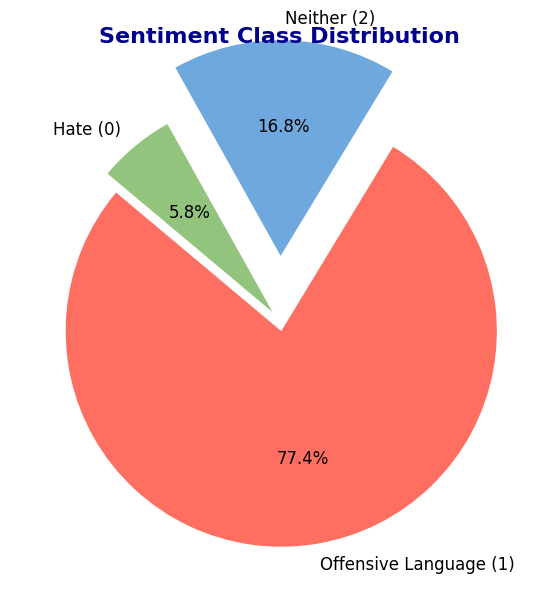

In [3]:
import matplotlib.pyplot as plt

# Count samples per class
class_counts = df['class'].value_counts()

# Define labels for each class
labels = ['Offensive Language (1)', 'Neither (2)', 'Hate (0)']

# Define colors for the pie chart
colors = ['#ff6f61', '#6fa8dc', '#93c47d']


explode = (0.05, 0.3, 0.05)  # Slightly separate each slice

# Create the pie chart
plt.figure(figsize=(10, 7))
plt.pie(
    class_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,  # Apply the cut
       # Adds subtle shadow for depth
    textprops={'fontsize': 12, 'color': 'black'}
)

# Add title
plt.title('Sentiment Class Distribution', fontsize=16, fontweight='bold', color='darkblue')

# Display the chart
plt.show()



### Checking correlation between classes

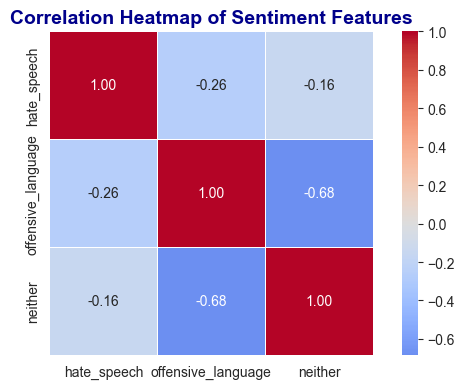

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = df[["hate_speech", "offensive_language", "neither"]].corr()

# Set up the figure
plt.figure(figsize=(6, 4))
sns.set_style("whitegrid")

# Plot the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

# Add title
plt.title("Correlation Heatmap of Sentiment Features", fontsize=14, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()


## Making data balanced 
#### Hate comment = 1413
#### by just taking offensive language comment = 1500
#### Neutral language comment = 1500

In [5]:
hate = df[df["class"]==0].sample(1413,random_state=42)
Offensive = df[df["class"]==1].sample(1500,random_state=42)
Neither = df[df["class"]==2].sample(1500,random_state=42)

balanced = pd.concat([hate,Offensive,Neither])
balanced["class"].value_counts()

class
1    1500
2    1500
0    1413
Name: count, dtype: int64

[Text(0, 0, 'Hate (0)'),
 Text(1, 0, 'Offensive Language (1)'),
 Text(2, 0, 'Neither (2)')]

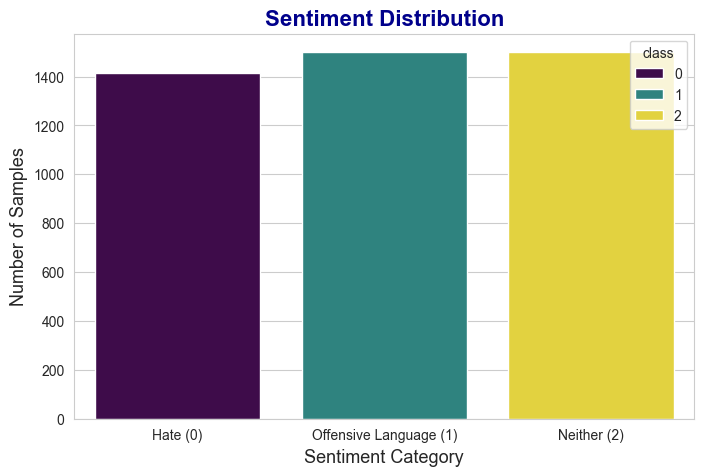

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='class', data=balanced, palette='viridis',hue='class')

# Add title and labels
plt.title("Sentiment Distribution", fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Sentiment Category", fontsize=13)
plt.ylabel("Number of Samples", fontsize=13)
ax.set_xticklabels(['Hate (0)','Offensive Language (1)', 'Neither (2)'])

In [8]:
balanced.to_csv(r"D:\NLP_assign2\data\training_data.csv", index=False)


#####  Checking null values

In [9]:
round(balanced.isnull().sum()/len(df)*100,2)

Unnamed: 0            0.0
count                 0.0
hate_speech           0.0
offensive_language    0.0
neither               0.0
class                 0.0
tweet                 0.0
dtype: float64

## Corelation between offensive language and neutral class after data balanced

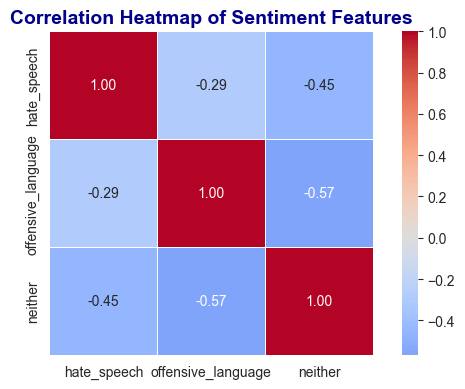

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = balanced[["hate_speech", "offensive_language", "neither"]].corr()

# Set up the figure
plt.figure(figsize=(6, 4))
sns.set_style("whitegrid")

# Plot the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

# Add title
plt.title("Correlation Heatmap of Sentiment Features", fontsize=14, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

## Result :

##### The heatmap shows a low correlation between the classes, indicating that the classes are well-separated and distinct from each other.
##### This is a positive outcome, as it suggests the model will be able to differentiate effectively between the classes when new textual input data is provided.

In [11]:
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zainch-032\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Cleaning the data set

In [12]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer


stop_words = set(stopwords.words('english'))

# 1️⃣ Text Cleaning Function
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize (split into words)
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Join back into a cleaned sentence
    cleaned_text = ' '.join(words)
    
    return cleaned_text.strip()



# OR if you prefer stemming instead of lemmatization
def stemming(text):
    ps = PorterStemmer()
    words = text.split()
    stemmed_words = [ps.stem(word) for word in words]
    return ' '.join(stemmed_words)

# Example usage
sample = "Cats are running faster than mice in the houses."

cleaned = clean_text(sample)

stemmed = stemming(cleaned)

print("Original:", sample)
print("Cleaned:", cleaned)

print("Stemmed:", stemmed)


Original: Cats are running faster than mice in the houses.
Cleaned: cats running faster mice houses
Stemmed: cat run faster mice hous


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Zainch-032\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
balanced["tweet"] = balanced["tweet"].apply(clean_text)
balanced["tweet"] = balanced["tweet"].apply(stemming)
balanced["tweet"].sample(3)


21118    southwest airlin like drive mini van white tra...
12727    man im tryna give chief keef mixtap chanc shit...
2136     cont also provid color sticker place nametag m...
Name: tweet, dtype: object

In [14]:
X = balanced['tweet']
y = balanced['class']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print how many samples ended up in the training and test sets.
print(len(X_train))
print(len(X_test))

# Display the training features (the tweet texts used for training)
X_train
X

3530
883


2499                    aust like talk faggot nice way fag
19697    rt mitchmancuso brantprintupwhat straight guy ...
5749     clinchmtn sixonesixband america today rule thu...
4615                               staccswntfold tell coon
15140                      rt faammoveral nigguh chri paul
                               ...                        
4992        thingsflppl yanke like florida state floridian
19629    rt markhoppu ye ye know fob reconcili idea you...
14780    rt couldbeeashia vivalamarley wait take ny get...
670      break ap call mass governor race charli baker ...
14410    rt blacknerdjad rt parkourlewi last hour rt th...
Name: tweet, Length: 4413, dtype: object

In [15]:
vectorizer = TfidfVectorizer(max_features=1500,ngram_range=(1,2),
    )
vectorizer.fit(X_train)

TfidfVectorizer(max_features=1500, ngram_range=(1, 2))

In [16]:
X_train_tfidf = vectorizer.transform(X_train)
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 22645 stored elements and shape (3530, 1500)>
  Coords	Values
  (0, 1431)	0.3527547920526562
  (0, 1428)	0.5891435503963818
  (0, 1345)	0.22694869185281083
  (0, 805)	0.4771098562810513
  (0, 395)	0.49933396641526967
  (1, 1304)	0.4189583847312747
  (1, 1098)	0.1635239732264377
  (1, 1003)	0.37196021401312535
  (1, 939)	0.45182479675094434
  (1, 248)	0.4473117472873655
  (1, 29)	0.5051197234464344
  (2, 1412)	0.3720215381807159
  (2, 1154)	0.4470454374873073
  (2, 1131)	0.3053746586696348
  (2, 758)	0.4545975780830993
  (2, 454)	0.4402898175199769
  (2, 453)	0.3790232969763245
  (2, 128)	0.15596130524025206
  (3, 810)	0.30965449223579333
  (3, 712)	0.5094988848019139
  (3, 495)	0.3843937980052764
  (3, 441)	0.30896325604941294
  (3, 117)	0.5094988848019139
  (3, 115)	0.3764558176942268
  (4, 1396)	0.28582951464739537
  :	:
  (3524, 123)	0.2797745186203182
  (3524, 58)	0.4836030435980572
  (3524, 45)	0.29505626651293027
  (35

In [17]:
X_train_tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),                 # convert sparse matrix to dense array
    columns=vectorizer.get_feature_names_out()  # use the learned vocabulary as column names
)

# Round all TF-IDF values to 2 decimal places for cleaner display.
X_train_tfidf_df = X_train_tfidf_df.round(2)

# Print a header for clarity and then show the first 5 rows of the DataFrame.
print("\nTF-IDF Features DataFrame (2 decimal places):")

X_train_tfidf_df.sample(5)


TF-IDF Features DataFrame (2 decimal places):


,abo,abus,accept,account,act,act like,actual,ad,add,admit,...,youd,youll,young,your,your faggot,your fuck,your retard,youtub,yu,yung
3096,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
895,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3212,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2361,0.0,0.0,0.0,0.43,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
732,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### When we convert text into vectors (via TF-IDF or Bag-of-Words), each document becomes a point in a very high-dimensional space (e.g., 6,000+ features).

➡️ Use Logistic Regression since the dataset is linearly separable and performs well for text classification tasks. 

In [18]:
X_test_tfidf = vectorizer.transform(X_test)


X_test_tfidf_df = pd.DataFrame(
    X_test_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Print a header for clarity and then show the first 5 rows of the DataFrame.
print("\nTF-IDF Features DataFrame:")
X_test_tfidf_df.head()

from sklearn.svm import SVC

# Initialize the SVM model
model = SVC(
    kernel='linear',     # Best for text data
    C=1.0,               # Regularization strength
    probability=True,    # Enable probability estimates
    random_state=42
)

model.fit(X_train_tfidf, y_train)



TF-IDF Features DataFrame:


SVC(kernel='linear', probability=True, random_state=42)

In [19]:
joblib.dump(model, r'D:\NLP_assign2\app\model\svc.pkl')
joblib.dump(vectorizer, r'D:\NLP_assign2\app\model\tfidf_vectorizer.pkl')


['D:\\NLP_assign2\\app\\model\\tfidf_vectorizer.pkl']

In [20]:
import joblib  

loaded_model = joblib.load( r'D:\NLP_assign2\app\model\svc.pkl')

loaded_vectorizer = joblib.load(r'D:\NLP_assign2\app\model\tfidf_vectorizer.pkl')

# Confirm that the model has been successfully loaded.
print("Model loaded from 'SVC.pkl'")

Model loaded from 'SVC.pkl'


In [21]:
X_test_tfidf_loaded = loaded_vectorizer.transform(X_test)

y_pred_loaded = loaded_model.predict(X_test_tfidf_loaded)

# Compute the accuracy of the loaded model on the test set.
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)

# Generate a detailed classification report (precision, recall, F1-score for each class).
report_loaded = classification_report(y_test, y_pred_loaded)

# Display the results.
print(f"Accuracy: {accuracy_loaded}")
print("Classification Report:")
print(report_loaded)

Accuracy: 0.8108720271800679
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.70      0.75       299
           1       0.77      0.82      0.79       304
           2       0.87      0.92      0.89       280

    accuracy                           0.81       883
   macro avg       0.81      0.81      0.81       883
weighted avg       0.81      0.81      0.81       883




Evaluation Metrics:


,Accuracy,Precision,Recall,F1-Score
0,0.810872,0.810271,0.810872,0.808945



Confusion Matrix Table:


,Predicted hate_speech,Predicted Offensive Language,Predicted Neither
Actual hate_speech,209,67,23
Actual Offensive Language,38,250,16
Actual Neither,15,8,257


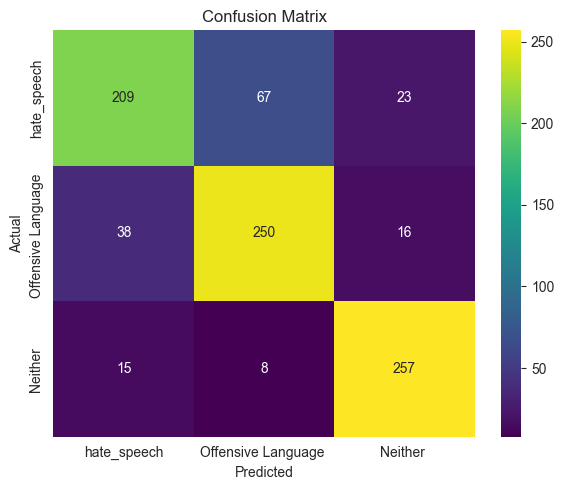

In [22]:

# --- Compute Evaluation Metrics ---

accuracy  = accuracy_score(y_test, y_pred_loaded)
precision = precision_score(y_test, y_pred_loaded, average='weighted')
recall    = recall_score(y_test, y_pred_loaded, average='weighted')
f1        = f1_score(y_test, y_pred_loaded, average='weighted')

metrics_df = pd.DataFrame({
    'Accuracy':  [accuracy],
    'Precision': [precision],
    'Recall':    [recall],
    'F1-Score':  [f1]
})

print("\nEvaluation Metrics:")
display(metrics_df)


# --- Confusion Matrix ---

conf_matrix = confusion_matrix(y_test, y_pred_loaded)
class_labels = ["hate_speech", 'Offensive Language ', 'Neither ']

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=[f'Actual {label}' for label in class_labels],
    columns=[f'Predicted {label}' for label in class_labels]
)

print("\nConfusion Matrix Table:")
display(conf_matrix_df)


# --- Plot the Confusion Matrix as a Heatmap ---

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    conf_matrix,
    annot=True, fmt='d', cmap='viridis',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


##### Model is performing well with 81.2% accuracy 